## **Performance of different optimizers on the XOR Problem**

We start by defining a function that allows us to plot the decision boundary which a trained model is able to come up with.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

In [ ]:
def plot_decision_boundary(plt, model, X, y, device="cpu", resolution=100):
    model.eval()
    model.to(device)

    # Define grid limits
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    # Prepare grid points
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)

    # Model prediction
    with torch.no_grad():
        preds = model(grid_tensor)
        preds = preds.squeeze().cpu().numpy()

    # Reshape predictions to grid
    Z = preds.reshape(xx.shape)

    # Plot contour and data points
    plt.contourf(xx, yy, Z > 0.5, alpha=0.4)
    # plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="coolwarm")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="False", s=40)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="True",  s=40)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")


def plot_losses(plt, losses):
    # Fix y-axis to 5 decimal places
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.5f'))
    plt.title("Loss History")

    # Display initial loss and final loss in the chart.
    plt.text(0.45, 0.92, f"Initial Loss: {losses[0]:.5f}", transform=plt.gca().transAxes)
    plt.text(0.45, 0.85, f"Final Loss:   {losses[-1]:.5f}", transform=plt.gca().transAxes)


def plot_y_y_pred(plt, model, X, y, device="cpu"):
    model.eval()
    model.to(device)

    # Model prediction
    with torch.no_grad():
        preds = model(X).squeeze().cpu().numpy()

    # Plot data points
    plt.scatter(y.squeeze().cpu().numpy(), preds, c=y, edgecolor="k", cmap="coolwarm")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs. Predicted Values")

## Define a Simple 2-Layer NN Model

We define a simple 3-Layer neural network model with 1 input layer, 1 hidden layer and 1 output layer.

We use the `nn.Sequential()` class to stack the 3 layers together without having to define a class.

The 3-layer model will have 2 input layers (corresponding to the two operands in an XOR problem), 4 hidden layers and 1 output layer.

In [ ]:
# Define the data for XOR Problem.
X_train = torch.tensor([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=torch.float32)
y_train = torch.tensor([0, 1, 1, 0], dtype=torch.float32)

In [ ]:
X_train = np.vstack([
    np.random.randn(1000, 2) * 0.5 + [-1, -1],
    np.random.randn(1000, 2) * 0.5 + [-1,  1],
    np.random.randn(1000, 2) * 0.5 + [ 1, -1],
    np.random.randn(1000, 2) * 0.5 + [ 1,  1],
])
y_train = np.array([0] * 1000 + [1] * 1000 + [1] * 1000 + [0] * 1000)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

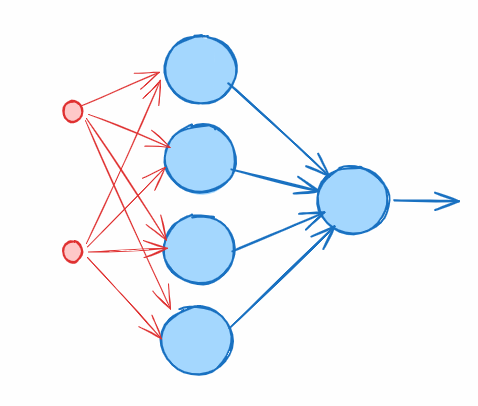

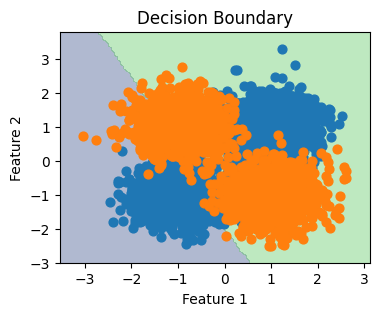

In [ ]:
# Define the model.
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

plt.figure(figsize=(4, 3))

# Plot decision boundary on the XOR Problem without any training.
plot_decision_boundary(
    plt=plt,
    model=model,
    X=X_train,
    y=y_train,
    device="cpu"
)

### **Implement Training Loop With Different Optimizers**

We will run multiple training loops with different optimizers, and for each optimizer we will print out the decision boundary after a fully trained network to see how well each optimizer does, along with the loss history.

We use same number of epochs, however, the starting learning rate differs depending on which optimizer is used.

In [ ]:
epochs = 1000

optimizers = [
    ("SGD", torch.optim.SGD(model.parameters(), lr=0.1)),
    ("RMSprop", torch.optim.RMSprop(model.parameters(), lr=0.01)),
    ("Momentum", torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)),
    ("Nesterov", torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)),
    ("Adam", torch.optim.Adam(model.parameters(), lr=0.01)),
    ("AdamW", torch.optim.AdamW(model.parameters(), lr=0.01)),
    ("NAdam", torch.optim.NAdam(model.parameters(), lr=0.1)),
    ("AdaGrad", torch.optim.Adagrad(model.parameters(), lr=0.1)),
    ("Adadelta", torch.optim.Adadelta(model.parameters(), lr=0.1)),
    ("Adamax", torch.optim.Adamax(model.parameters(), lr=0.1)),
    ("Rprop", torch.optim.Rprop(model.parameters(), lr=0.1)),
    ("ASGD", torch.optim.ASGD(model.parameters(), lr=0.1)),
]

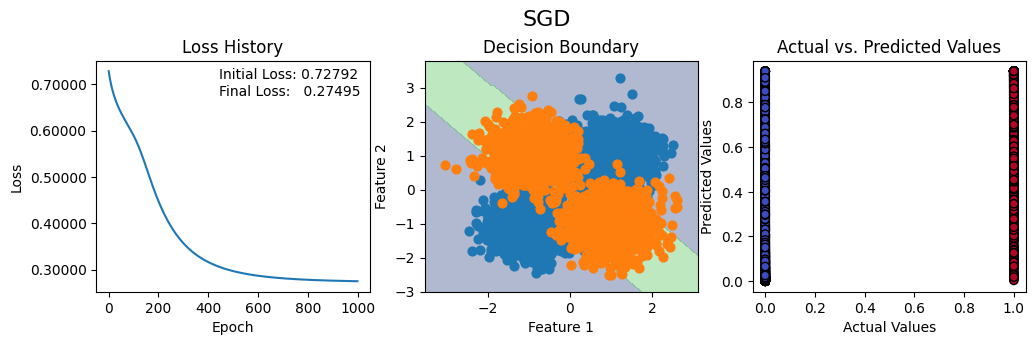

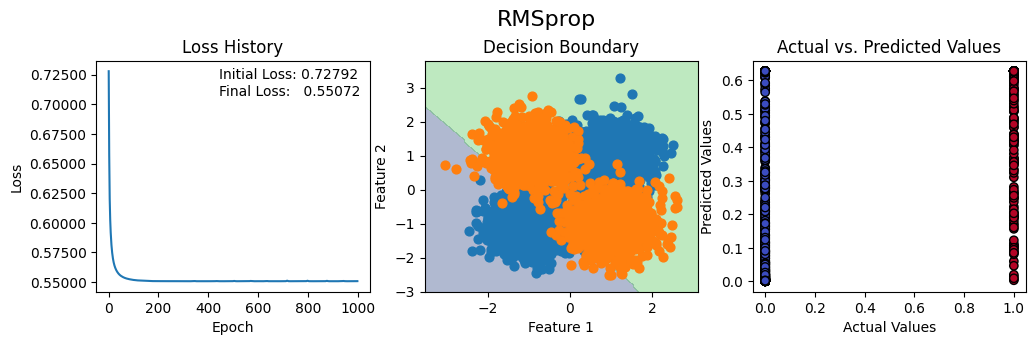

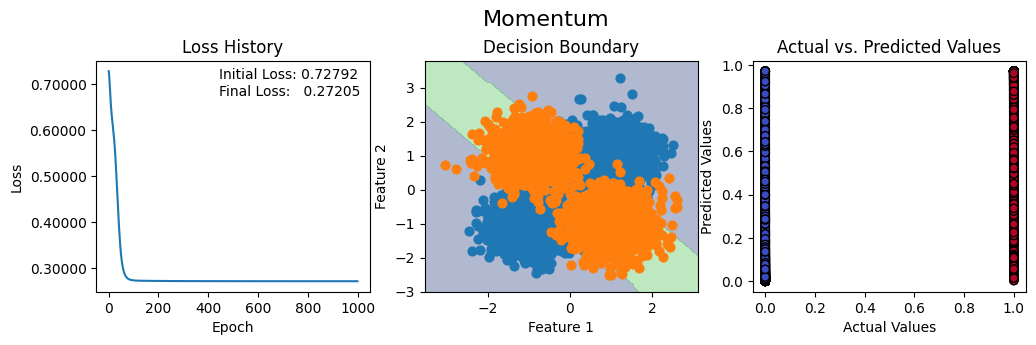

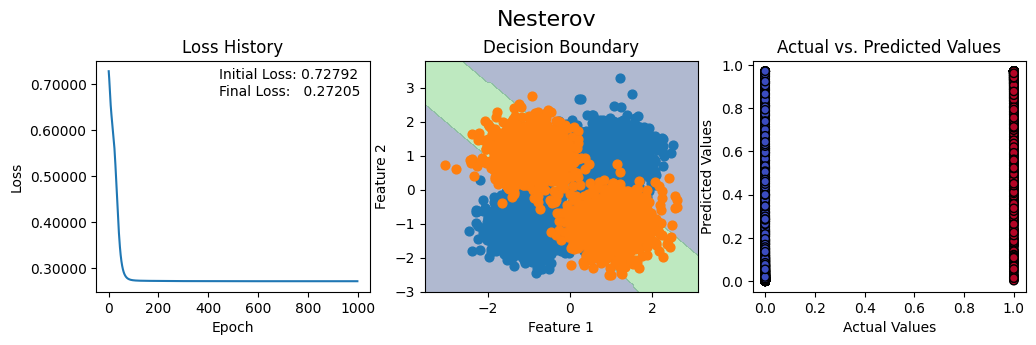

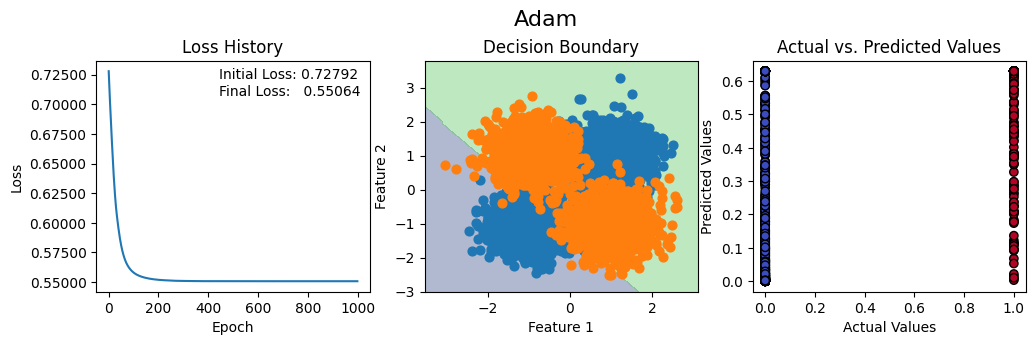

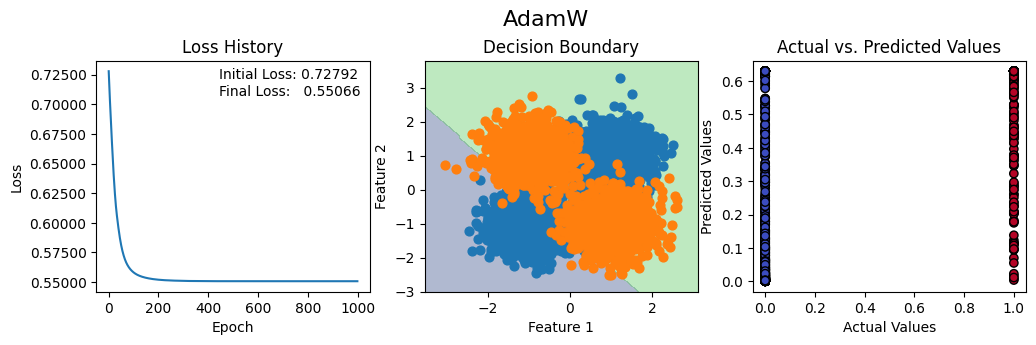

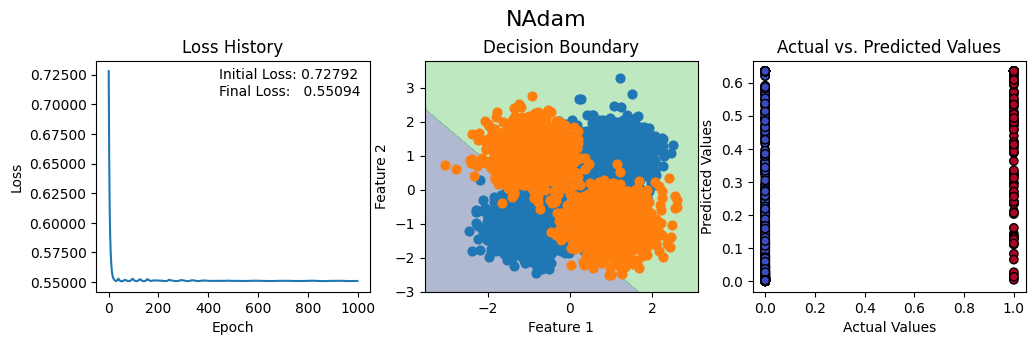

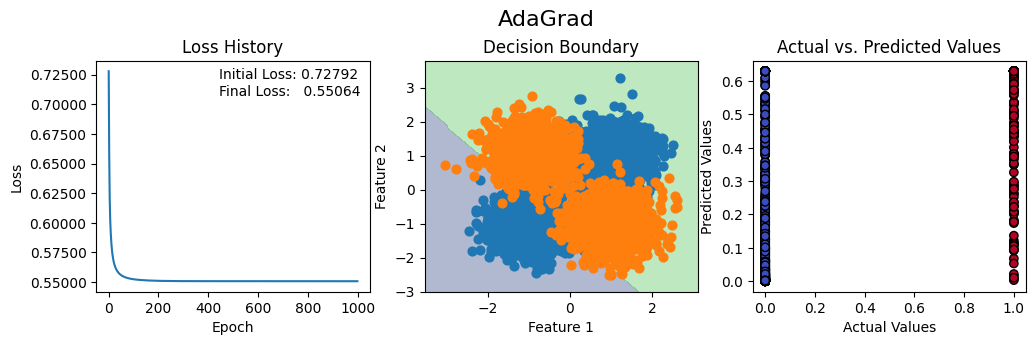

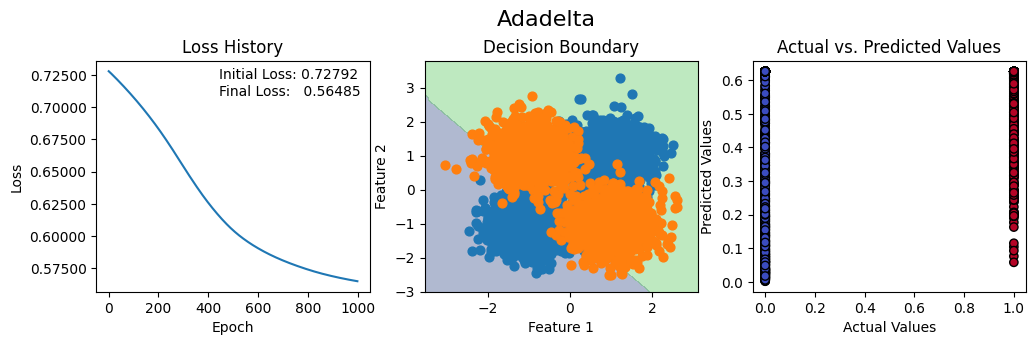

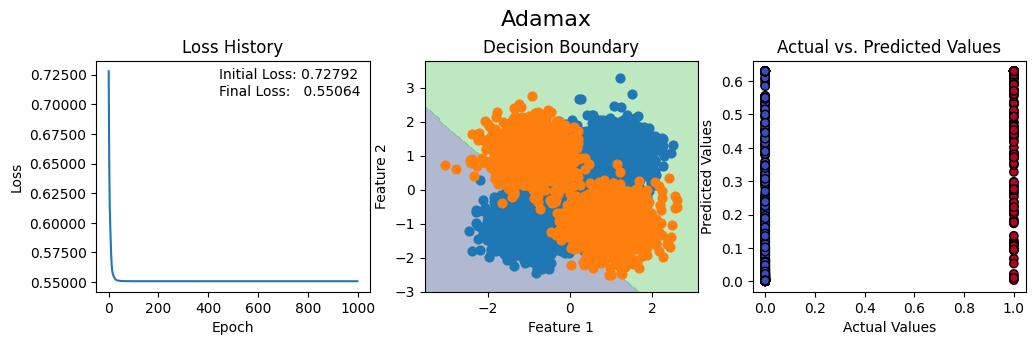

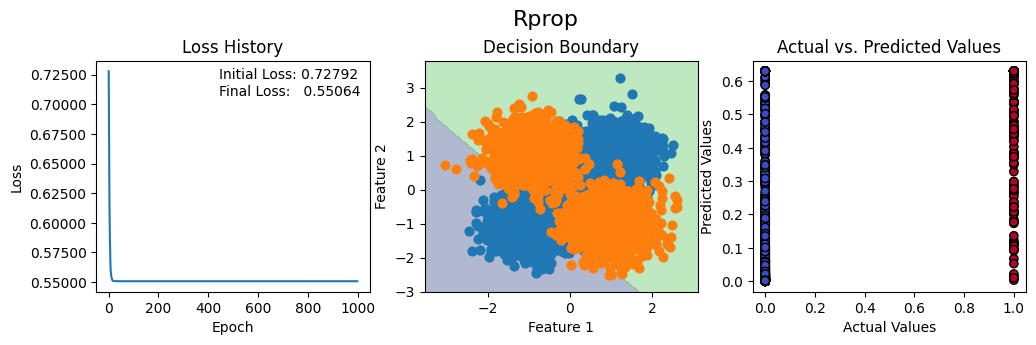

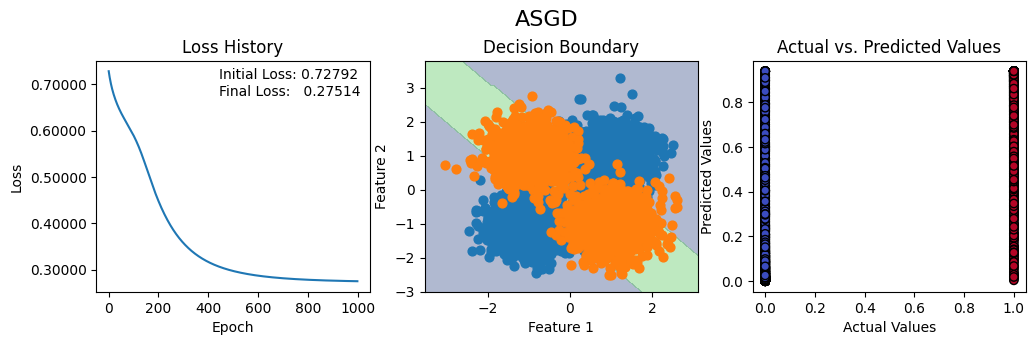

In [ ]:
# Training loop
loss_fn = nn.BCELoss()
# loss_fn = nn.MSELoss()
losses = {}

# Backup initial parameters, to eliminate variations due to randomness.
initial_params = [param.clone() for param in model.parameters()]

for optimizer_name, optimizer in optimizers:
    # Restore initial parameters.
    for param, initial_param in zip(model.parameters(), initial_params):
        param.data = initial_param.clone()
    model.train()

    losses[optimizer_name] = []

    # Training loop.
    for epoch in range(epochs):
        # Forward pass and loss calculation.
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train.view(-1, 1))

        # Backward pass and optimization.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Loss history accumulation.
        losses[optimizer_name].append(loss.item())

    # Plot loss history and decision boundary of trained model.
    plt.figure(figsize=(12, 3))

    # Plot optimizer name above chart figure.
    plt.suptitle(optimizer_name, fontsize=16, y=1.05)

    plt.subplot(1, 3, 1)
    plot_losses(plt, losses[optimizer_name])

    plt.subplot(1, 3, 2)
    plot_decision_boundary(
        plt=plt,
        model=model,
        X=X_train,
        y=y_train,
        device="cpu"
    )

    plt.subplot(1, 3, 3)
    plot_y_y_pred(
        plt=plt,
        model=model,
        X=X_train,
        y=y_train,
        device="cpu"
    )

In [ ]:
# Find optimizer with lowest final loss.
min_loss = float('inf')
min_optimizer = None
for optimizer_name, optimizer in optimizers:
    if losses[optimizer_name][-1] < min_loss:
        min_loss = losses[optimizer_name][-1]
        min_optimizer = optimizer_name

print(f"The optimizer with the lowest final loss ({min_loss}) is: {min_optimizer}")

The optimizer with the lowest final loss (0.2720521092414856) is: Nesterov
